In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from polyergalio.models.model_loss import MSELoss
from polyergalio.models.optimizers import SGD, Adam
from polyergalio.models.layers.basal_layers import (
    FullyConnectedLayer,
    DropoutLayer,
    NormalizeLayer,
    RMSNormLayer
)
from polyergalio.models.layers.operator_layers import LatentStack, LatentSum, ShiftRight
from polyergalio.models.layers.mixture_layers import PoolingLayer
from polyergalio.models.layers.fft_layers import FrequencyFFT
from polyergalio.models.layers.spectre_layers import SpectreAttention, SpectreDecoderAttention
from polyergalio.models.embedding.positional import SinusoidEmbedding

import matplotlib.pyplot as plt

MAX_POSSIBLE_WINDOWS = 2**10


In [2]:
from polyergalio.encoders.audio_encoders import (AudioProcessor,
                                              read_wav,
                                              window_size_from_ms,
                                              plot_waveform,
                                              plot_spectrogram,
                                              plot_window_spectra,
                                              build_windows,
                                              progressive_downsample)

WINDOW_LENGTH_MS = 600 # our window length for plotting
sample_rate, waveform_l = read_wav("../test.wav", channel=0)
sample_rate, waveform_r = read_wav("../test.wav", channel=1)

time_per_sample = 1000 / sample_rate
samples_per_window = window_size_from_ms(sample_rate, WINDOW_LENGTH_MS)
# samples_per_window = WINDOW_LENGTH_MS / time_per_sample
real_positive_fft_shape = (samples_per_window // 2) + 1


print(time_per_sample, "ms per sample step")
print(f"Each {WINDOW_LENGTH_MS} ms window will be composed of {samples_per_window} samples")
print(f"Fourier Transform will yield {real_positive_fft_shape} frequency bins")

audio_enc = AudioProcessor(
    sample_rate=sample_rate,
    window_ms = WINDOW_LENGTH_MS,
    overlap_ratio= 1/3, # how much of the window is overlapping with previous step
    use_decibels = True,
    target = "waveform",
    variable_idx = 0
)


encoded_data = audio_enc.fit_encode(waveform_l)
print(audio_enc.metadata)
print("amplitude", encoded_data["amplitude"].shape, "\nfrequency spectrum:", encoded_data["spectrum"].shape)


0.010416666666666666 ms per sample step
Each 600 ms window will be composed of 57600 samples
Fourier Transform will yield 28801 frequency bins
{'target': 'waveform', 'variable_idx': 0, 'sample_rate': 96000, 'window_ms': 600, 'window_size': 57600, 'num_overlap': 19200, 'num_frequencies': 547219, 'use_decibels': True}
amplitude (19, 57600) 
frequency spectrum: (19, 28801)


/Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/polyergalio/encoders/audio_encoders.py:108: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, waveform = wavfile.read(file_path)


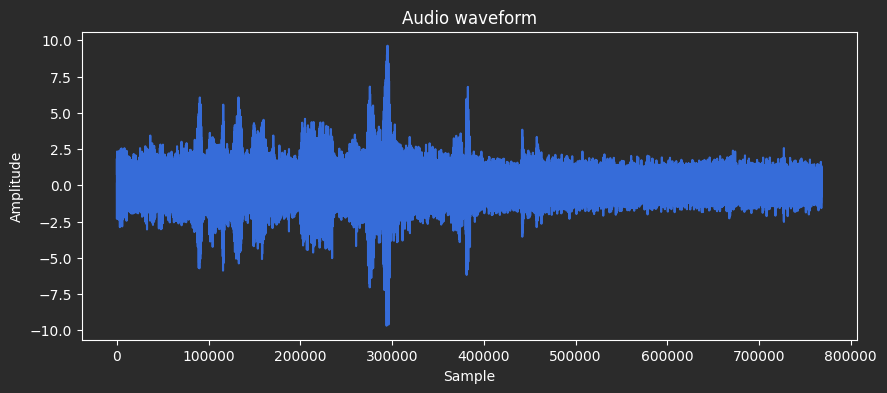

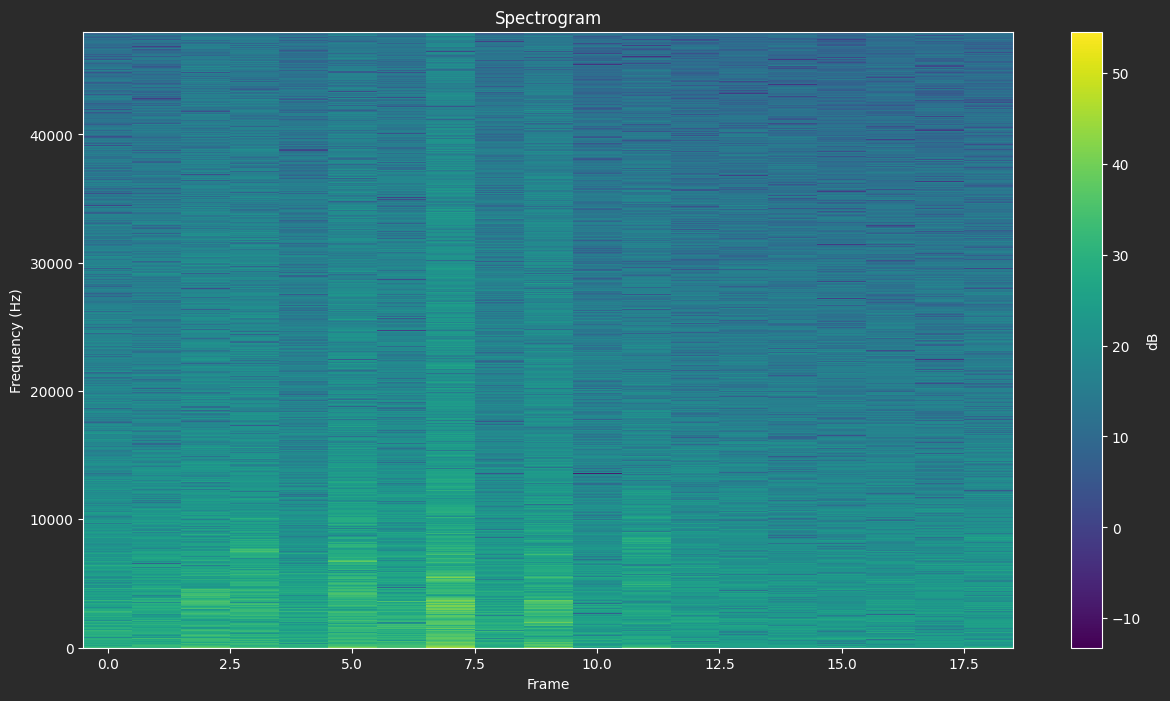

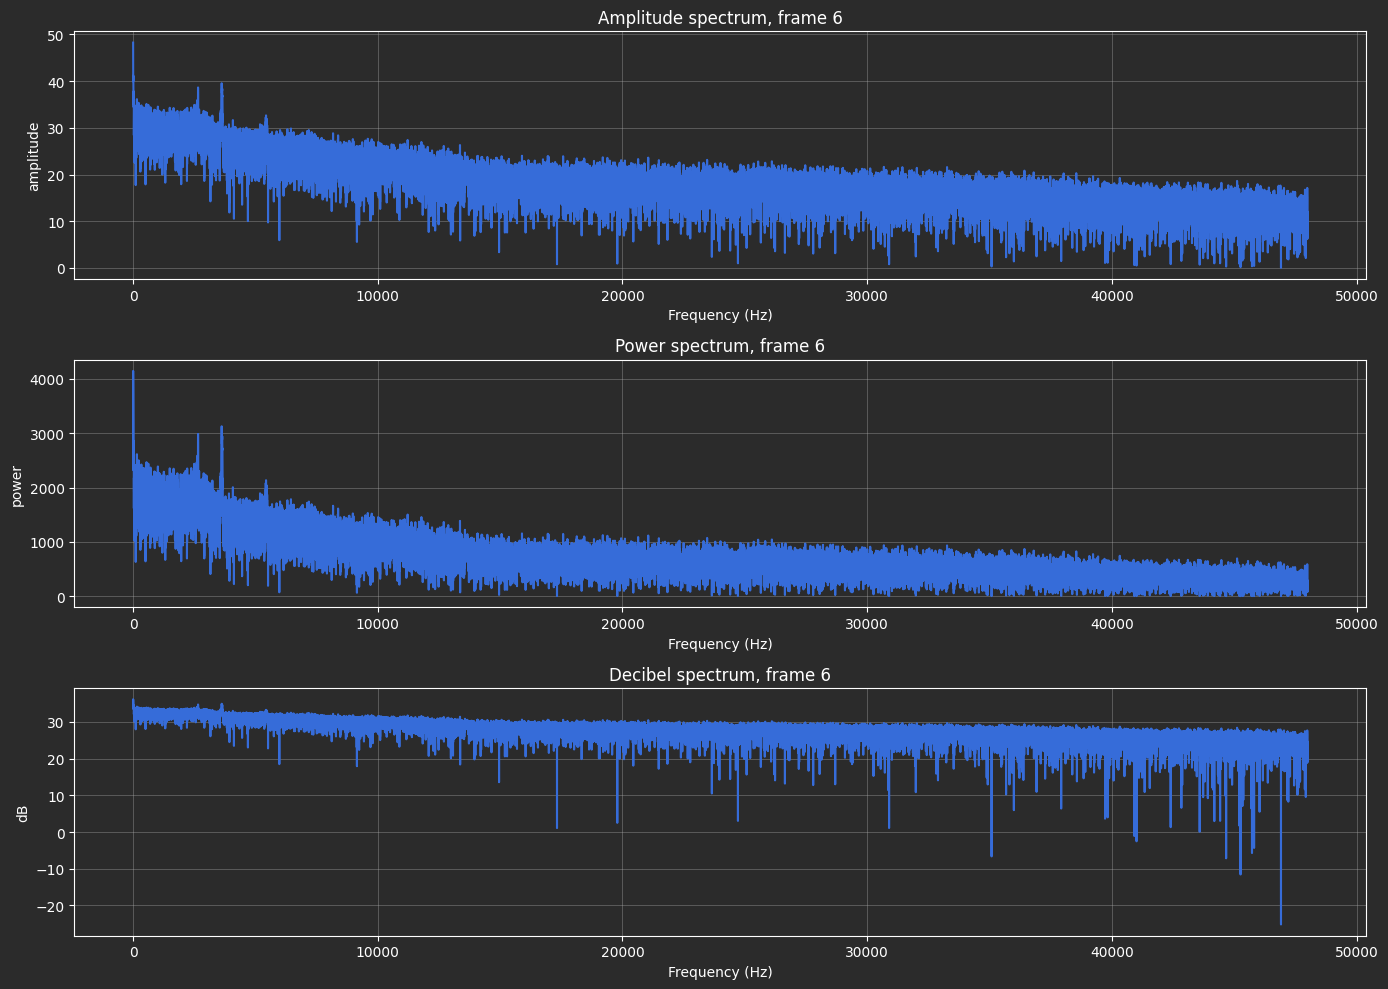

In [3]:
plot_waveform(waveform_l)
plot_spectrogram(encoded_data["spectrum"].real, audio_enc.freqs)
plot_window_spectra(
        encoded_data["spectrum"].real, audio_enc.freqs, index=6, window_size=time_per_sample
    )


In [4]:
# loading our audio files:
import os
WINDOW_LENGTH_MS = 50 # our window length

all_windowed_data = []

all_filenames = os.listdir(f"../data/")
for fn in all_filenames:
    if fn.endswith(".wav"):

        sample_rate, waveform_l = read_wav(f"../data/{fn}", channel=0)
        time_per_sample = 1000 / sample_rate
        samples_per_window = window_size_from_ms(sample_rate, WINDOW_LENGTH_MS)
        # samples_per_window = WINDOW_LENGTH_MS / time_per_sample
        real_positive_fft_shape = (samples_per_window // 2) + 1


        audio_enc = AudioProcessor(
            sample_rate=sample_rate,
            window_ms = WINDOW_LENGTH_MS,
            overlap_ratio= 1/4, # how much of the window is overlapping with previous step
            use_decibels = True,
            target = "waveform",
            variable_idx = 0
        )

        encoded_data_l = audio_enc.fit_encode(waveform_l)["amplitude"]
        list_of_array = [encoded_data_l]

        try:
            sample_rate, waveform_r = read_wav(f"../data/{fn}", channel=1)
            encoded_data_r = audio_enc.fit_encode(waveform_r)["amplitude"]
            list_of_array.append(encoded_data_r)
        except:
            pass

        all_windowed_data.extend(list_of_array)

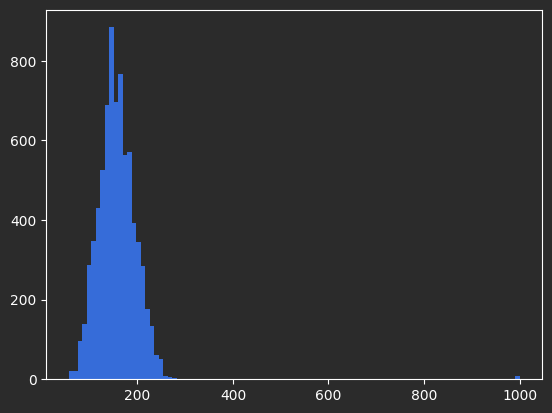

3941


In [5]:
shapes = []
np.random.shuffle(all_windowed_data)

for windowed_data in all_windowed_data:
    shapes.append(windowed_data.shape[0])

plt.hist(np.clip(shapes, min=0, max=1000), bins=100)
plt.show()
print(np.max(shapes))

In [6]:
# MAX_POSSIBLE_WINDOWS should be optimized for specific lengths of FFT: closest to: (2**10 * N)
# MAX_POSSIBLE_WINDOWS = 2**10 * 1
MAX_POSSIBLE_WINDOWS = 600


# pad our sequences to max:
xs = np.zeros((len(all_windowed_data), MAX_POSSIBLE_WINDOWS, samples_per_window))
padding_mask = np.zeros((len(all_windowed_data), MAX_POSSIBLE_WINDOWS))
for idx, data in enumerate(all_windowed_data):
    l, n = data.shape
    l = min(l, MAX_POSSIBLE_WINDOWS)
    xs[idx, :l, :] = data[:l, ...]
    padding_mask[idx, :l] = 1

print(xs.shape)
print(padding_mask.shape)

(7504, 600, 200)
(7504, 600)


In [7]:
# downsample the data -- this could be helpful? or not... not sure yet.
#
# downs = progressive_downsample(xs, mask=padding_mask, factors=[2, 2, 2])
#
# for dim in downs:
#     print(dim[0].shape, dim[1].shape)

In [8]:
# let's take a subsample of the data
# xs = xs[:500, ...]
# padding_mask = padding_mask[:500, ...]

In [9]:
print(xs.shape, padding_mask.shape)

(7504, 600, 200) (7504, 600)


In [10]:
MAX_POSSIBLE_WINDOWS

600

edges:
  input      -> amp_a
  amp_a      -> amp_b
  amp_b      -> amp_c
  input      -> freq_fft
  freq_fft   -> freq_fc
  amp_c      -> stack
  freq_fc    -> stack
  stack      -> position
  position   -> project
  project    -> enc1_attn
  enc1_attn  -> enc1_a
  enc1_a     -> enc1_b
  enc1_b     -> enc1_norm
  enc1_norm  -> enc1_drop
  project    -> enc2_residualconn
  enc1_drop  -> enc2_residualconn
  enc2_residualconn -> enc2_prenorm
  enc2_prenorm -> enc2_attn
  enc2_attn  -> enc2_a
  enc2_a     -> enc2_b
  enc2_b     -> enc2_norm
  enc2_norm  -> enc2_drop
  project    -> enc3_residualconn
  enc2_drop  -> enc3_residualconn
  enc3_residualconn -> enc3_prenorm
  enc3_prenorm -> enc3_attn
  enc3_attn  -> enc3_a
  enc3_a     -> enc3_b
  enc3_b     -> enc3_norm
  enc3_norm  -> enc3_drop
  project    -> enc4_residualconn
  enc3_drop  -> enc4_residualconn
  enc4_residualconn -> enc4_prenorm
  enc4_prenorm -> enc4_attn
  enc4_attn  -> enc4_a
  enc4_a     -> enc4_b
  enc4_b     -> enc4_no

<Axes: title={'center': 'audio_encoder_decoder'}>

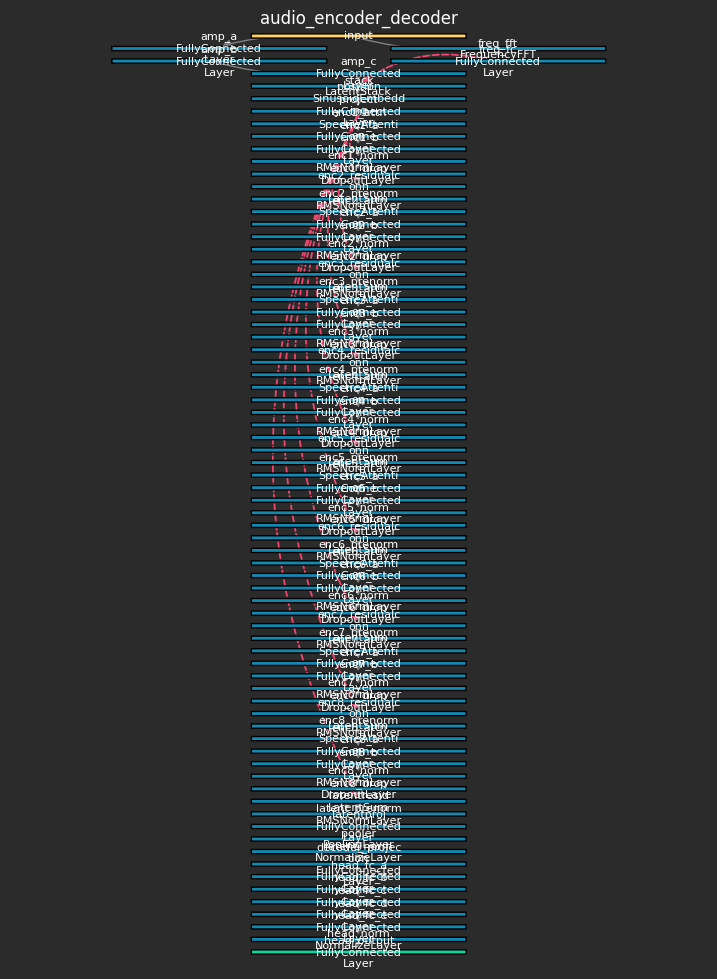

In [13]:
from polyergalio.models.neural_network import Node, NeuralNetwork
from polyergalio.visuals.nnet_visuals import plot_network

EMBEDDING_DIM = 1200
HIDDEN_DIM = 800
NUM_HEADS=10
# latent space bottleneck
LATENT_DIMENSION = 1200

# samples_per_window = the samples per window (final dimesion of xs)

net = NeuralNetwork(name="audio_encoder_decoder", input_shape=(samples_per_window,))
windows = net.input

# (num_samples, seq_length, window_dimension)

# amplitude branch: funnel the raw window down to the latent width
amplitude = net.connect(FullyConnectedLayer(samples_per_window, EMBEDDING_DIM, "relu"), windows, name="amp_a")
amplitude = net.connect(FullyConnectedLayer(EMBEDDING_DIM, real_positive_fft_shape, "relu"), amplitude, name="amp_b")
amplitude = net.connect(FullyConnectedLayer(real_positive_fft_shape, EMBEDDING_DIM, "linear"), amplitude, name="amp_c")

# frequency branch. `windows` is used a second time here, which is the fan-out
frequency = net.connect(FrequencyFFT(MAX_POSSIBLE_WINDOWS, samples_per_window), windows, name="freq_fft")
frequency = net.connect(FullyConnectedLayer(samples_per_window, EMBEDDING_DIM, "linear"), frequency, name="freq_fc")

# the branches merge, then get positional information
mixed = net.connect(LatentStack(), amplitude, frequency, name="stack")
mixed = net.connect(SinusoidEmbedding(MAX_POSSIBLE_WINDOWS, 2 * EMBEDDING_DIM), mixed, name="position")
mixed = net.connect(FullyConnectedLayer(2*EMBEDDING_DIM, HIDDEN_DIM, "linear"), mixed, name="project")

# encoder
enc1 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=20,
                                    memory_tokens=50,
                                    use_wrm=True), mixed, name="enc1_attn")
enc1 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc1, name="enc1_a")
enc1 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc1, name="enc1_b")
enc1 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc1, name="enc1_norm")
enc1 = net.connect(DropoutLayer(dropout_prob=0.05), enc1, name="enc1_drop")


# encoder2 ------------------
enc2 = net.connect(LatentSum(), mixed, enc1, name="enc2_residualconn")
enc2 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc2, name="enc2_prenorm")
enc2 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=10,
                                    memory_tokens=50,
                                    use_wrm=True), enc2, name="enc2_attn")
enc2 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc2, name="enc2_a")
enc2 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc2, name="enc2_b")
enc2 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc2, name="enc2_norm")
enc2 = net.connect(DropoutLayer(dropout_prob=0.05), enc2, name="enc2_drop")


#  encoder3 ------------------
enc3 = net.connect(LatentSum(), mixed, enc2, name="enc3_residualconn")
enc3 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc3, name="enc3_prenorm")
enc3 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=10,
                                    memory_tokens=50,
                                    use_wrm=True), enc3, name="enc3_attn")
enc3 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc3, name="enc3_a")
enc3 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc3, name="enc3_b")
enc3 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc3, name="enc3_norm")
enc3 = net.connect(DropoutLayer(dropout_prob=0.05), enc3, name="enc3_drop")


#  encoder4 ------------------
enc4 = net.connect(LatentSum(), mixed, enc3, name="enc4_residualconn")
enc4 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc4, name="enc4_prenorm")
enc4 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=5,
                                    memory_tokens=50,
                                    use_wrm=True), enc4, name="enc4_attn")
enc4 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc4, name="enc4_a")
enc4 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc4, name="enc4_b")
enc4 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc4, name="enc4_norm")
enc4 = net.connect(DropoutLayer(dropout_prob=0.05), enc4, name="enc4_drop")


#  encoder5 ------------------
enc5 = net.connect(LatentSum(), mixed, enc4, name="enc5_residualconn")
enc5 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc5, name="enc5_prenorm")
enc5 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=2,
                                    memory_tokens=50,
                                    use_wrm=True), enc5, name="enc5_attn")
enc5 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc5, name="enc5_a")
enc5 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc5, name="enc5_b")
enc5 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc5, name="enc5_norm")
enc5 = net.connect(DropoutLayer(dropout_prob=0.05), enc5, name="enc5_drop")


#  encoder6 ------------------
enc6 = net.connect(LatentSum(), mixed, enc5, name="enc6_residualconn")
enc6 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc6, name="enc6_prenorm")
enc6 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=1,
                                    memory_tokens=50,
                                    use_wrm=True), enc6, name="enc6_attn")
enc6 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc6, name="enc6_a")
enc6 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc6, name="enc6_b")
enc6 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc6, name="enc6_norm")
enc6 = net.connect(DropoutLayer(dropout_prob=0.05), enc6, name="enc6_drop")


#  encoder 7 ------------------
enc7 = net.connect(LatentSum(), mixed, enc6, name="enc7_residualconn")
enc7 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc7, name="enc7_prenorm")
enc7 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=1,
                                    memory_tokens=75,
                                    use_wrm=True), enc7, name="enc7_attn")
enc7 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc7, name="enc7_a")
enc7 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc7, name="enc7_b")
enc7 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc7, name="enc7_norm")
enc7 = net.connect(DropoutLayer(dropout_prob=0.05), enc7, name="enc7_drop")


#  encoder 8 ------------------
enc8 = net.connect(LatentSum(), mixed, enc7, name="enc8_residualconn")
enc8 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc8, name="enc8_prenorm")
enc8 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=1,
                                    memory_tokens=75,
                                    use_wrm=True), enc8, name="enc8_attn")
enc8 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc8, name="enc8_a")
enc8 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), enc8, name="enc8_b")
enc8 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc8, name="enc8_norm")
enc8 = net.connect(DropoutLayer(dropout_prob=0.05), enc8, name="enc8_drop")


#  Latent ------------------------------------------------------------------------------------------
latent = net.connect(LatentSum(), mixed, enc8, name="latentresid")
latent = net.connect(RMSNormLayer(HIDDEN_DIM), latent, name="latent_prenorm")
latent = net.connect(FullyConnectedLayer(HIDDEN_DIM, LATENT_DIMENSION, "linear"), latent, name="latentproj")
pooler = net.connect(PoolingLayer(), latent, name="pooler")
pooler = net.connect(NormalizeLayer(LATENT_DIMENSION), pooler, name="latent_norm")


# -------- DECODER ------------------
# shifted = net.connect(ShiftRight(hidden_dim=HIDDEN_DIM), mixed, name="shift_right")
# shifted_noisy = net.connect(DropoutLayer(dropout_prob=0.75), shifted, name="teacher_dropout")
# decoded = net.connect(SpectreDecoderAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
#                                             hidden_dim=HIDDEN_DIM,
#                                             num_heads=NUM_HEADS,
#                                             band_radius=1,
#                                             memory_tokens=128,
#                                             use_wrm=False), shifted_noisy, name="decoder_attn")
#
latent_broadcast = net.connect(
    FullyConnectedLayer(LATENT_DIMENSION, HIDDEN_DIM, "linear"),
    pooler,
    name="decoder_projection")
#
# head_inputs = net.connect(LatentSum(), latent_broadcast, shifted_noisy, name="head_inputs")


# -------- HEAD -------------------------
# decoded = net.connect(LatentSum(), head_inputs, decoded, name="head_residual")

head = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), latent_broadcast, name="head_fc_a")
head = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), head, name="head_fc_b")
head = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), head, name="head_fc_c")
head = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), head, name="head_fc_d")
head = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "swish"), head, name="head_fc_e")
head = net.connect(NormalizeLayer(HIDDEN_DIM, shift_scale=True), head, name="head_norm")
net.output = net.connect(FullyConnectedLayer(HIDDEN_DIM, samples_per_window, "linear", is_output=True), head, name="head_output")


print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")
print()
print(net.summary(xs[0:2, :, :]))
print(net.timing_summary(top=10))
plot_network(net)


In [ ]:
# AND this is how we train:
%pdb on
BATCH_SIZE = 20
EPOCHS = 1
STEPS_PER_SAMPLE = 1
LR = 4e-4
DIVI = 10

loss = MSELoss()
optimizer = Adam(LR)
all_losses = []
verbose=False
idx_shuffler = np.arange(len(xs))


for epoch in range(EPOCHS):
    net.train()
    LR *= 0.88
    print(f'EPOCH {epoch}, lr decaying to {LR}')

    np.random.shuffle(idx_shuffler)

    # decay rate for LR
    optimizer.learning_rate *= 0.90

    _permuted_xs = xs[idx_shuffler, ...]
    _permuted_mask = padding_mask[idx_shuffler, ...]
    for step_i, batch_st in enumerate(range(0, len(xs), BATCH_SIZE)):
        verbose = (step_i + 1) % DIVI == 0

        _xs = _permuted_xs[batch_st:batch_st+BATCH_SIZE, :, :]
        _pad = _permuted_mask[batch_st:batch_st+BATCH_SIZE, :]

        # break if we don't have enough samples left
        if _xs.shape[0] != BATCH_SIZE:
            continue
        for _ in range(STEPS_PER_SAMPLE):

            x_prime = net.forward(_xs, mask=_pad)
            reconstruction_loss = loss.forward(prediction=x_prime, targets=_xs, mask=_pad)

            all_losses.append(reconstruction_loss.item())

            net.backward(loss.backward())
            optimizer.step(net.layers)
            net.zero_gradients()

        if verbose:
            print(f"step {_ + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")

    print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")
    plt.plot(all_losses)
    plt.title("reconstruction loss")
    plt.show()

plt.plot(all_losses)
plt.title("reconstruction loss")
plt.show()

Automatic pdb calling has been turned ON
EPOCH 0, lr decaying to 0.00035200000000000005


In [ ]:
windowed_data.shape
x_prime.shape
plt.plot(all_losses)
plt.title("reconstruction loss")
plt.show()

In [ ]:
# visualize some of the input data and predictions
for idx in range(min(x_prime.shape[0], 3)):
    plt.figure()
    plt.subplot(2,2, 1)
    plt.plot(x_prime[idx, 3, :])
    plt.subplot(2,2, 2)
    plt.plot(xs[0, 3, :])
    plt.show()
    plt.subplot(2,2, (3,4))
    plt.plot((x_prime[idx, 3, :] - xs[idx, 3, :]), color="red", alpha=0.2)
    plt.show()